# VVV — Análisis de Periodo con Lomb-Scargle
### 50 estrellas aleatorias · Curva de luz · Periodograma · Curva de fase

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import random

from astropy.io import fits
from astropy.timeseries import LombScargle

## 1 · Carga de datos

In [11]:
VVV_data = fits.open('VVV_Sample.fits')

Id_b278,  Id_b279  = VVV_data[1].data,  VVV_data[11].data

Ks_b278,  Ks_b279  = VVV_data[2].data,  VVV_data[12].data
dKs_b278, dKs_b279 = VVV_data[5].data,  VVV_data[15].data
mjd_b278, mjd_b279 = VVV_data[8].data,  VVV_data[18].data

VVV_data.info()

Filename: VVV_Sample.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      11   ()      
  1  ID_B278       1 ImageHDU         7   (304,)   int64   
  2  KS_B278       1 ImageHDU         8   (523, 304)   float64   
  3  H_B278        1 ImageHDU         8   (32, 304)   float64   
  4  J_B278        1 ImageHDU         8   (25, 304)   float64   
  5  KS_ERR_B278    1 ImageHDU         8   (523, 304)   float64   
  6  H_ERR_B278    1 ImageHDU         8   (32, 304)   float64   
  7  J_ERR_B278    1 ImageHDU         8   (25, 304)   float64   
  8  KS_MJD_B278    1 ImageHDU         8   (523, 304)   float64   
  9  H_MJD_B278    1 ImageHDU         8   (32, 304)   float64   
 10  J_MJD_B278    1 ImageHDU         8   (25, 304)   float64   
 11  ID_B279       1 ImageHDU         7   (286,)   int64   
 12  KS_B279       1 ImageHDU         8   (960, 286)   float64   
 13  H_B279        1 ImageHDU         8   (14, 286)   float64   
 14  J_B279        1

## 2 · Limpieza de NaNs

In [12]:
def remove_nans(array2d):
    """Elimina NaNs fila a fila."""
    return [row[~np.isnan(row)] for row in array2d]

Ks_b278  = remove_nans(Ks_b278)
dKs_b278 = remove_nans(dKs_b278)
mjd_b278 = remove_nans(mjd_b278)

Ks_b279  = remove_nans(Ks_b279)
dKs_b279 = remove_nans(dKs_b279)
mjd_b279 = remove_nans(mjd_b279)

## 3 · Parámetros clave de Lomb-Scargle
Ajustar el rango y resolución de la búsqueda de periodos.

In [30]:
# ──────────────────────────────────────────────
#   PARÁMETROS DE LOMB-SCARGLE
# ──────────────────────────────────────────────

P_MIN   = 0.1      # Periodo mínimo de prueba (días)
P_MAX   = 50.0    # Periodo máximo de prueba (días)
N_FREQ  = 5000   # Número de frecuencias de prueba

N_STARS = 50       # Cantidad de estrellas aleatorias a analizar

# ──────────────────────────────────────────────
#   Frecuencias derivadas de los periodos
# ──────────────────────────────────────────────
FREQ_MIN = 1.0 / P_MAX   # frecuencia mínima  (1/día)
FREQ_MAX = 1.0 / P_MIN   # frecuencia máxima  (1/día)

# Grilla de frecuencias equiespaciada
test_frequencies = np.linspace(FREQ_MIN, FREQ_MAX, N_FREQ)

## 4 · Funciones auxiliares

In [31]:
def get_phases(t, mag, period):
    """
    Calcula las fases plegadas al periodo dado.
    El tiempo de referencia t0 se ancla al percentil 2% de la magnitud
    (punto más brillante aproximado).
    """
    threshold = np.percentile(mag, 2)
    t0 = t[np.argmin(np.abs(mag - threshold))]
    return ((t - t0) / period) % 1


def plot_star(star_id, t, mag, dmag, freq_grid, ax_lc, ax_pgram, ax_phase):
    """
    Calcula el periodograma Lomb-Scargle y genera tres paneles:
      · ax_lc    : curva de luz  (MJD vs magnitud)
      · ax_pgram : periodograma  (periodo vs potencia)
      · ax_phase : curva de fase (fase 0-2 vs magnitud)
    """
    # ── Lomb-Scargle ────────────────────────────────────────────────────
    ls    = LombScargle(t, mag, dmag)
    power = ls.power(freq_grid)

    best_freq   = freq_grid[np.argmax(power)]
    best_period = 1.0 / best_freq
    best_power  = power.max()

    periods_grid = 1.0 / freq_grid

    # ── Curva de luz ─────────────────────────────────────────────────────
    ax_lc.scatter(t, mag, c='k', s=2)
    ax_lc.set_xlabel('MJD (días)')
    ax_lc.set_ylabel('Ks (mag)')
    ax_lc.set_title(f'ID {star_id}  —  Curva de luz', fontsize=9)
    ax_lc.invert_yaxis()

    # ── Periodograma ─────────────────────────────────────────────────────
    # Ordenar por periodo creciente para que la línea se trace correctamente
    sort_idx = np.argsort(periods_grid)
    ax_pgram.plot(periods_grid[sort_idx], power[sort_idx], c='steelblue', lw=0.7)
    ax_pgram.axvline(best_period, color='red', linestyle='--', lw=1.2,
                     label=f'P = {best_period:.4f} d')
    ax_pgram.set_xlabel('Periodo (días)')
    ax_pgram.set_ylabel('Potencia LS')
    ax_pgram.set_title(f'Periodograma  —  P$_{{\\rm best}}$ = {best_period:.4f} d', fontsize=9)
    ax_pgram.legend(fontsize=7, loc='upper right')

    # ── Curva de fase (0 → 2) ────────────────────────────────────────────
    phase = get_phases(t, mag, best_period)
    phase2 = np.concatenate([phase, phase + 1])
    mag2   = np.concatenate([mag,   mag])

    ax_phase.scatter(phase2, mag2, c='k', s=2)
    ax_phase.set_xlabel('Fase')
    ax_phase.set_ylabel('Ks (mag)')
    ax_phase.set_title(f'Curva de fase  —  P = {best_period:.8f} d', fontsize=9)
    ax_phase.set_xlim(0, 2)
    ax_phase.invert_yaxis()

    return best_freq, best_period

## 5 · Selección aleatoria y análisis

In [32]:
# Selección aleatoria reproducible (cambia la semilla si quieres otra muestra)
random.seed(2004)
N_total      = Id_b278.shape[0]
selected_idx = random.sample(range(N_total), N_STARS)

print(f"Total de estrellas disponibles : {N_total}")
print(f"Estrellas seleccionadas        : {N_STARS}")
print(f"Rango de periodos de prueba    : [{P_MIN}, {P_MAX}] días")
print(f"Número de frecuencias          : {N_FREQ}")

Total de estrellas disponibles : 304
Estrellas seleccionadas        : 50
Rango de periodos de prueba    : [0.1, 50.0] días
Número de frecuencias          : 5000


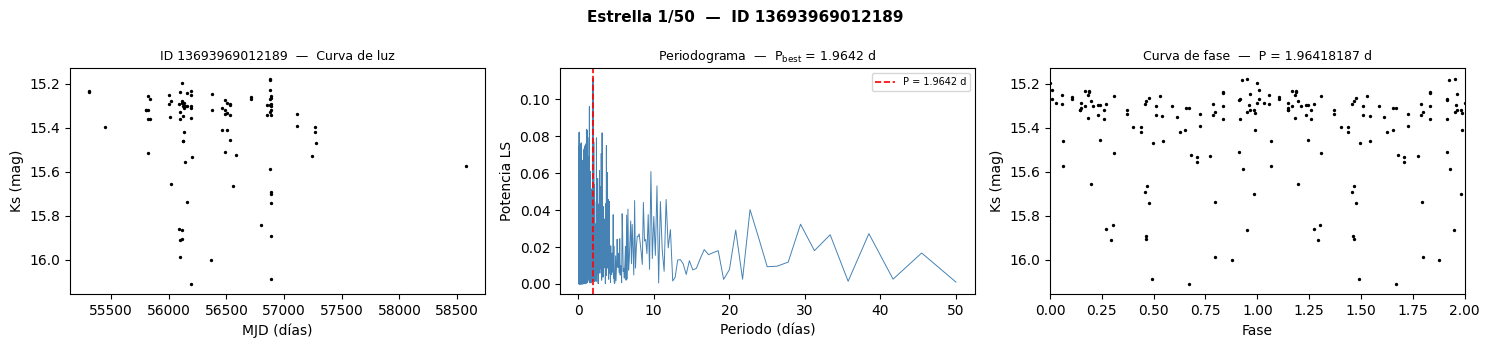

[01/50] ID 13693969012189  →  P = 1.96418187 días


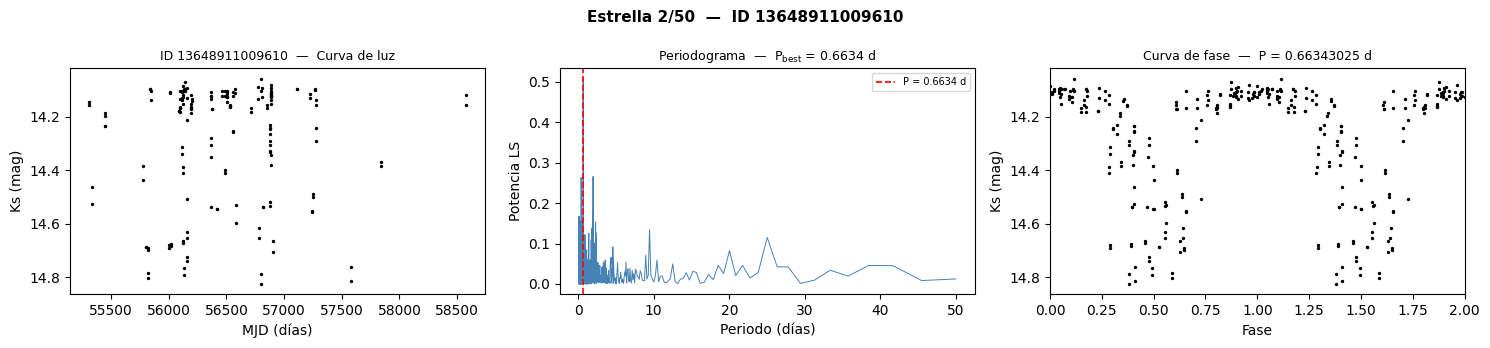

[02/50] ID 13648911009610  →  P = 0.66343025 días


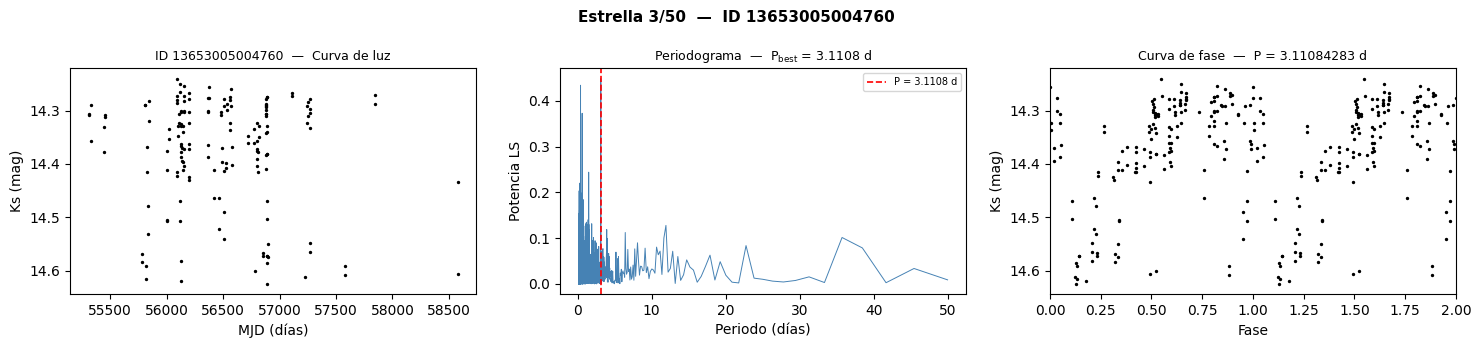

[03/50] ID 13653005004760  →  P = 3.11084283 días


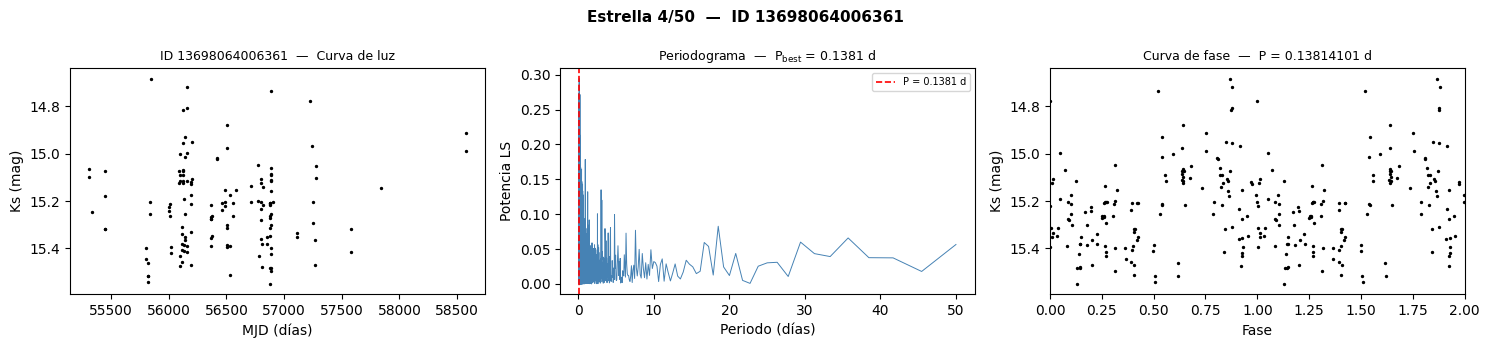

[04/50] ID 13698064006361  →  P = 0.13814101 días


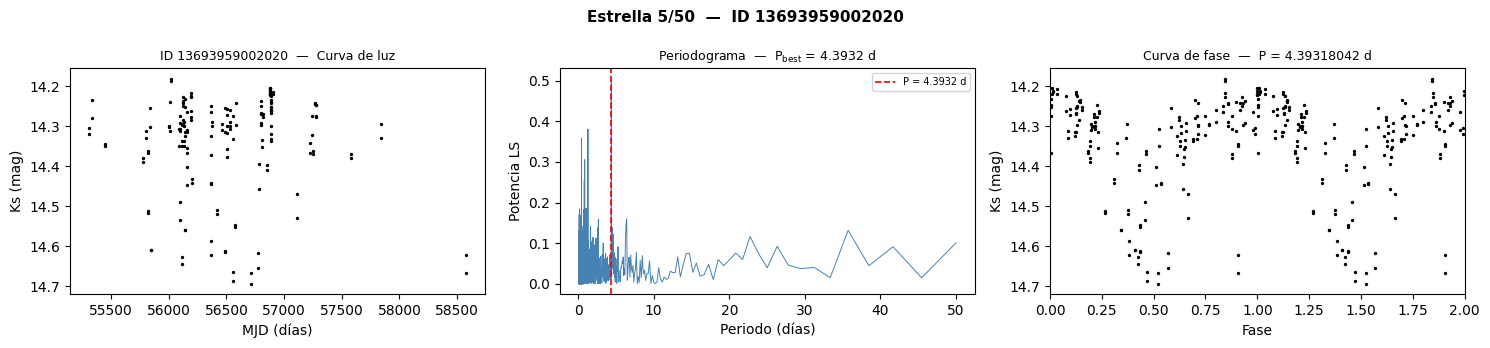

[05/50] ID 13693959002020  →  P = 4.39318042 días


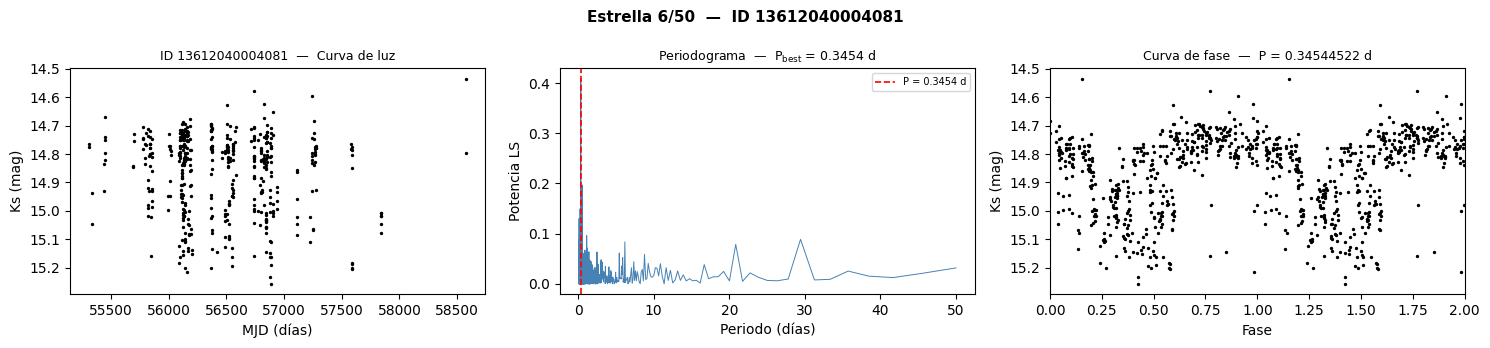

[06/50] ID 13612040004081  →  P = 0.34544522 días


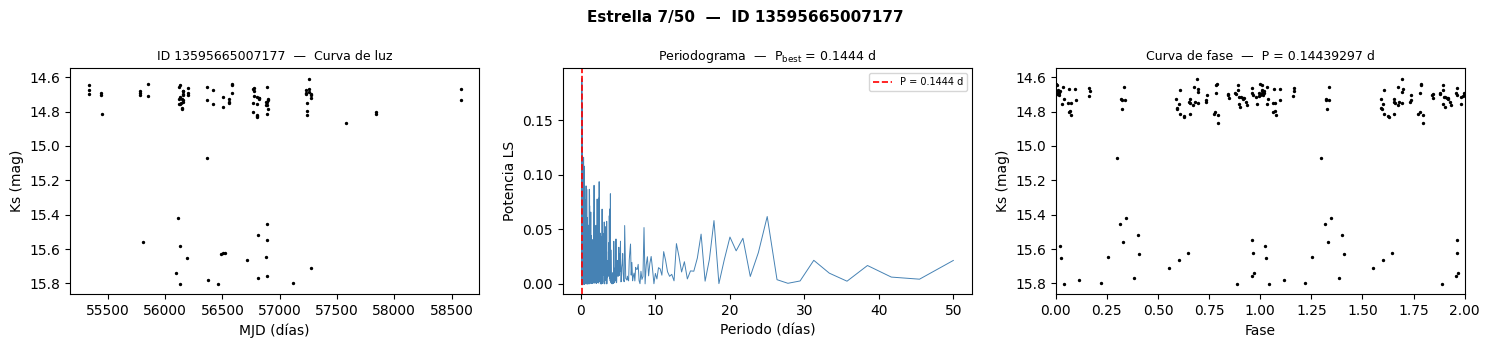

[07/50] ID 13595665007177  →  P = 0.14439297 días


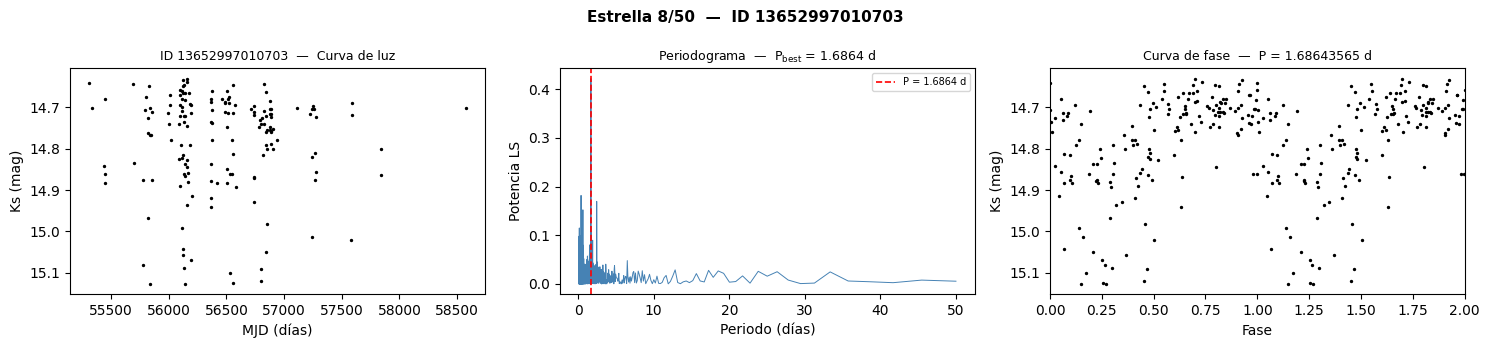

[08/50] ID 13652997010703  →  P = 1.68643565 días


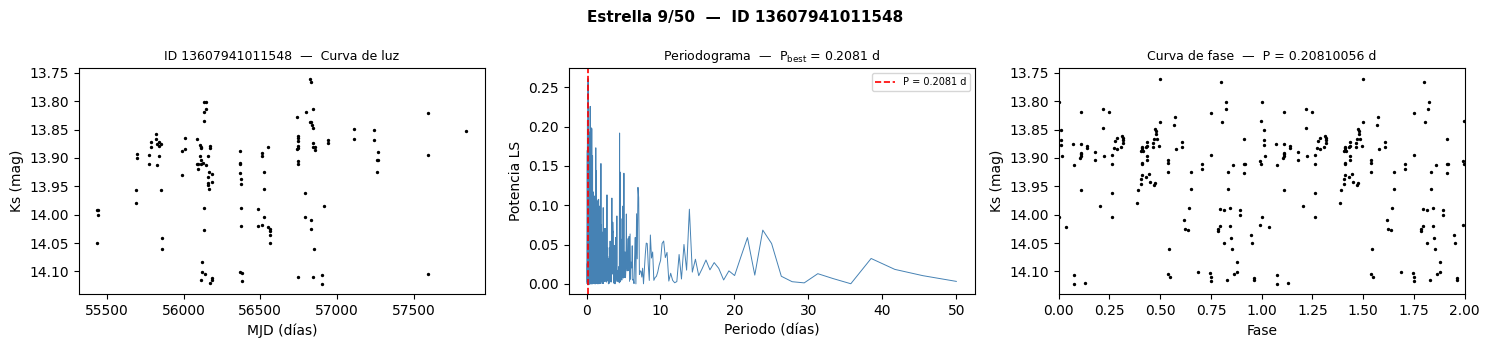

[09/50] ID 13607941011548  →  P = 0.20810056 días


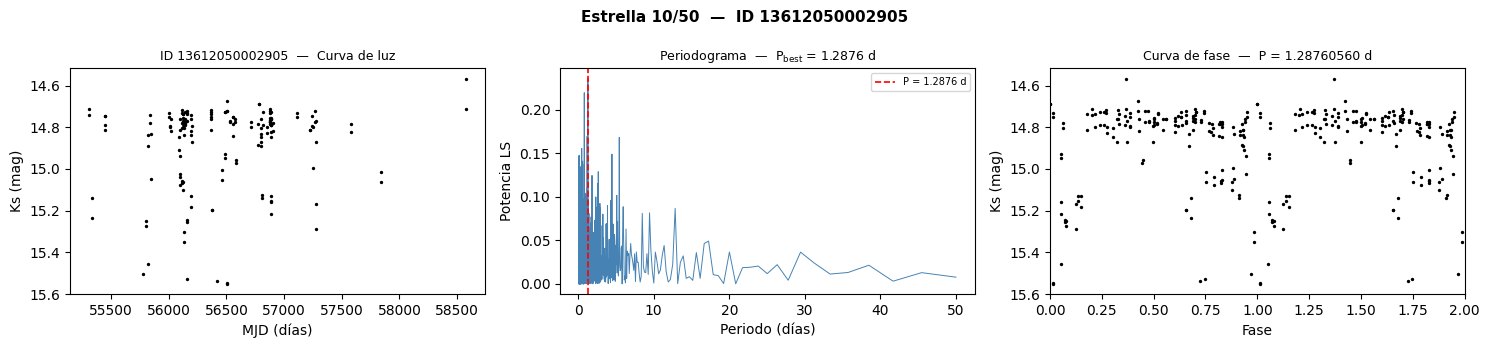

[10/50] ID 13612050002905  →  P = 1.28760560 días


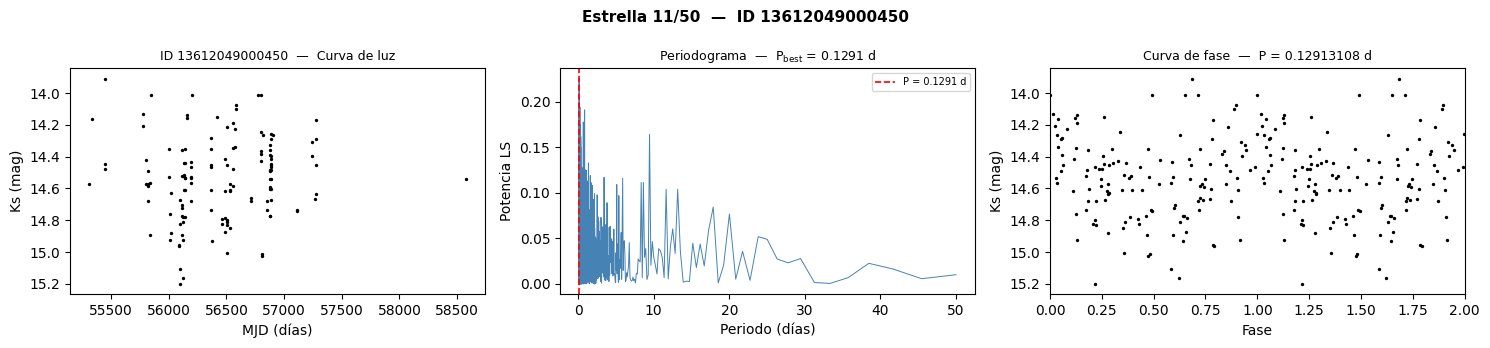

[11/50] ID 13612049000450  →  P = 0.12913108 días


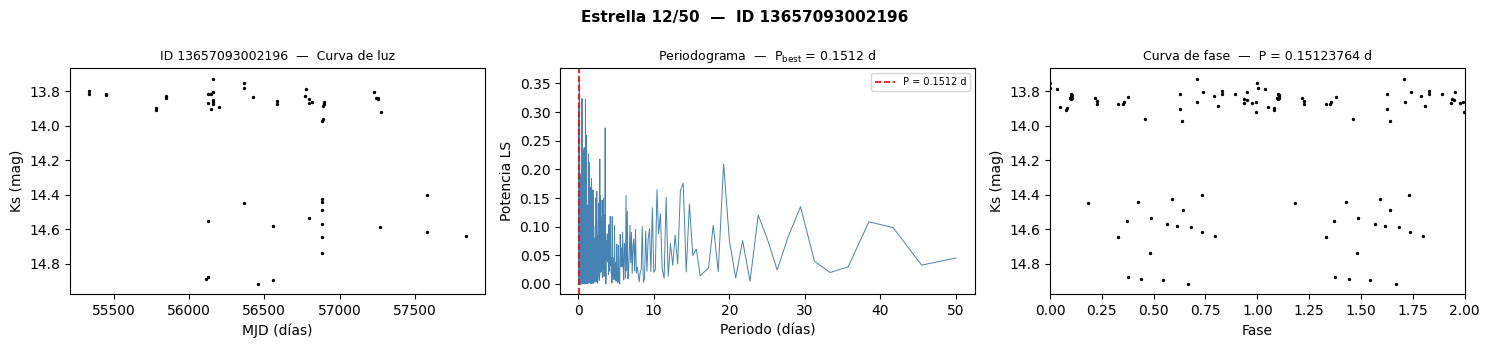

[12/50] ID 13657093002196  →  P = 0.15123764 días


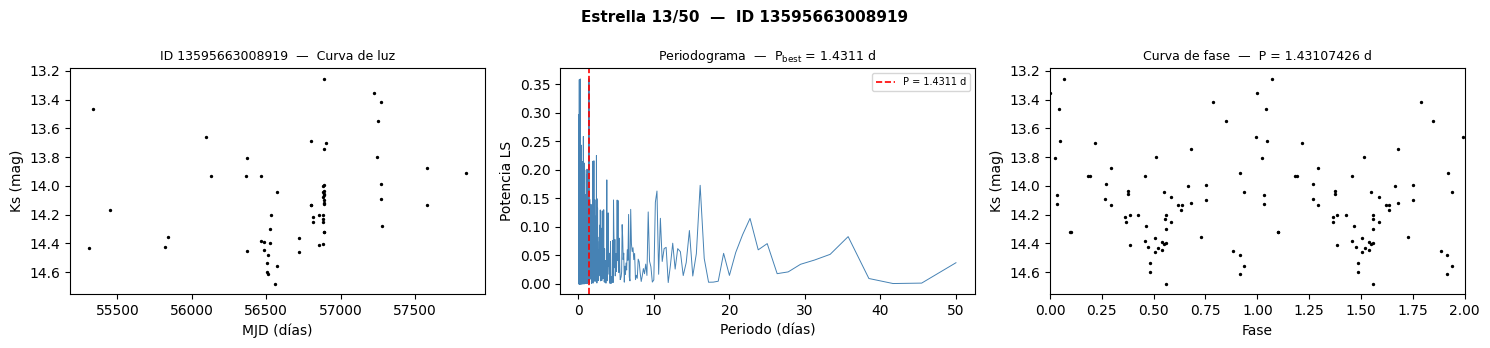

[13/50] ID 13595663008919  →  P = 1.43107426 días


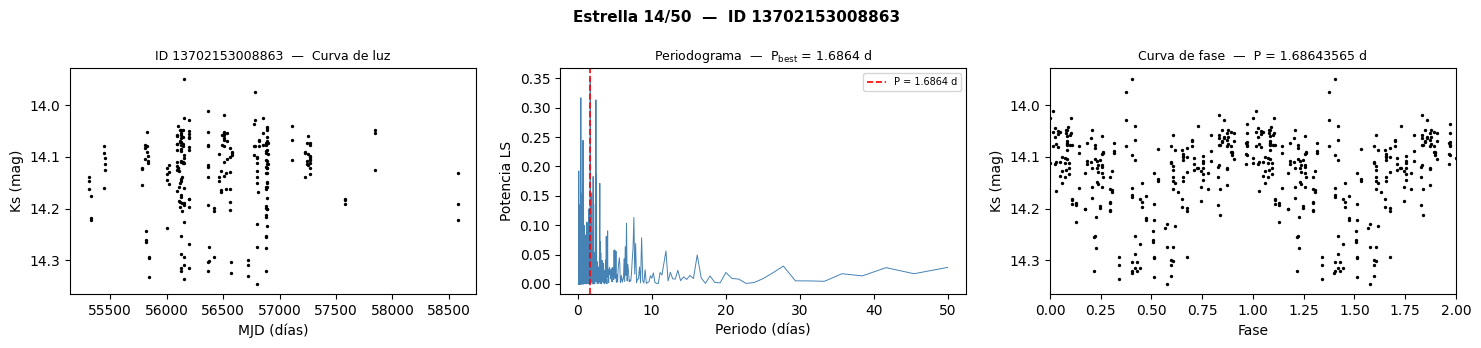

[14/50] ID 13702153008863  →  P = 1.68643565 días


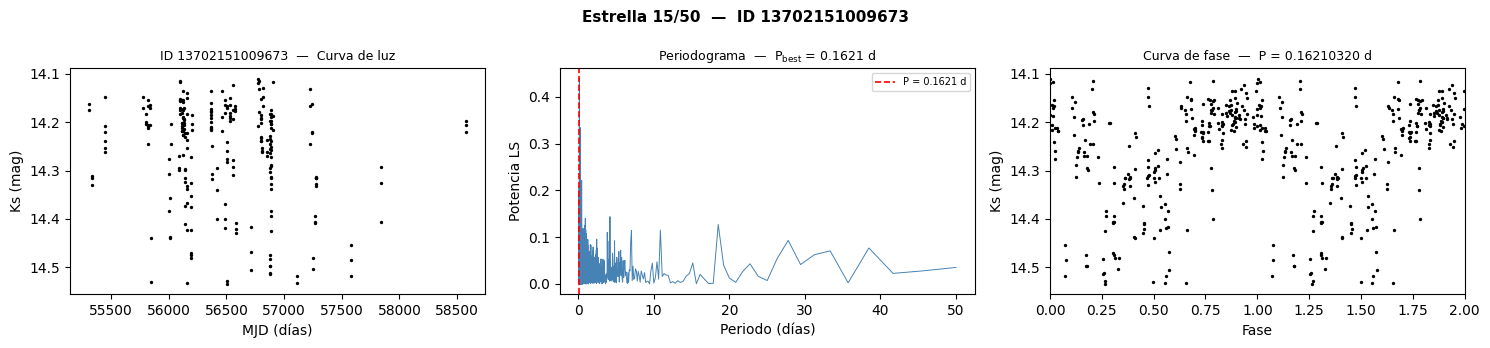

[15/50] ID 13702151009673  →  P = 0.16210320 días


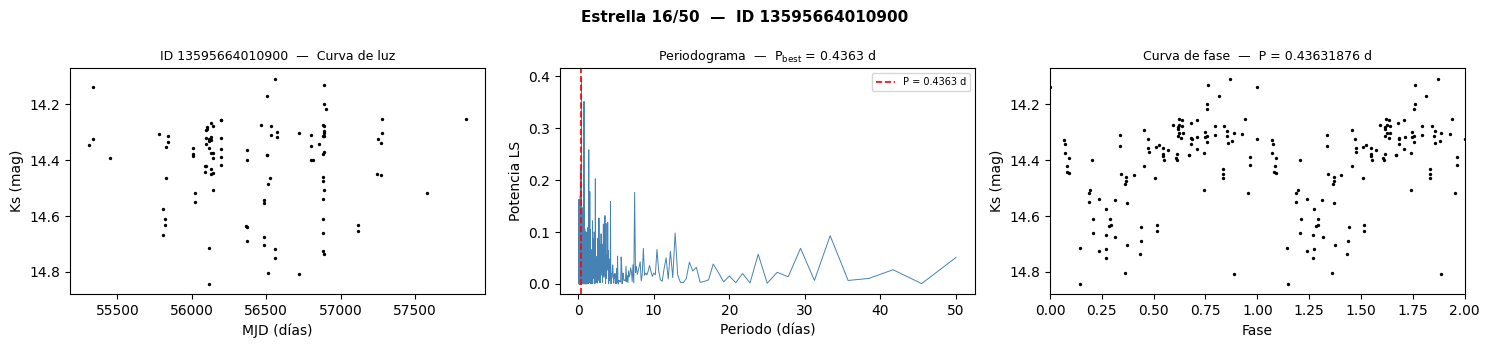

[16/50] ID 13595664010900  →  P = 0.43631876 días


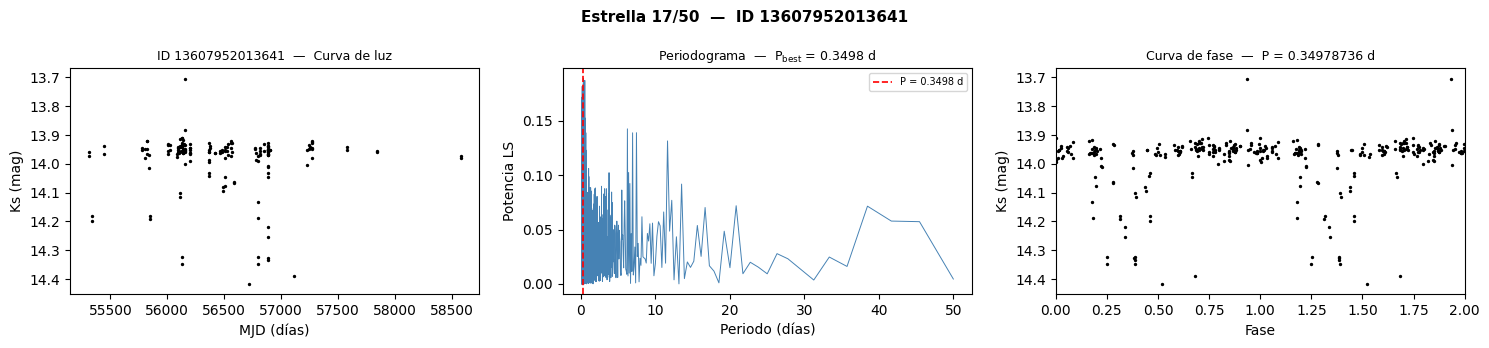

[17/50] ID 13607952013641  →  P = 0.34978736 días


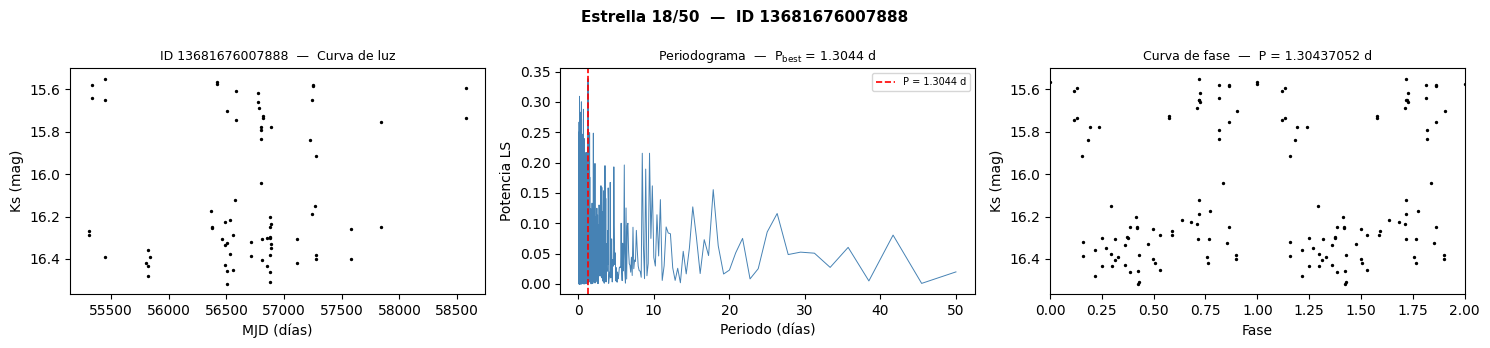

[18/50] ID 13681676007888  →  P = 1.30437052 días


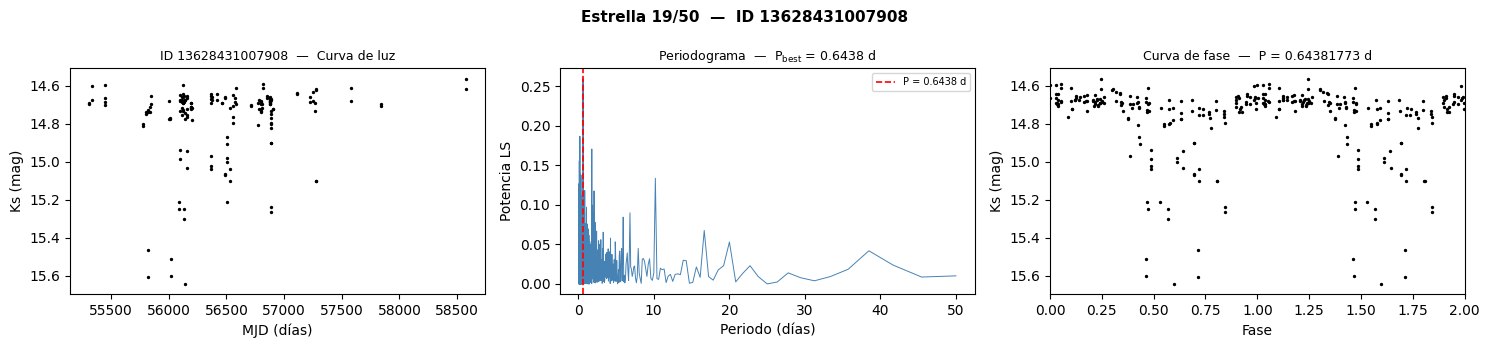

[19/50] ID 13628431007908  →  P = 0.64381773 días


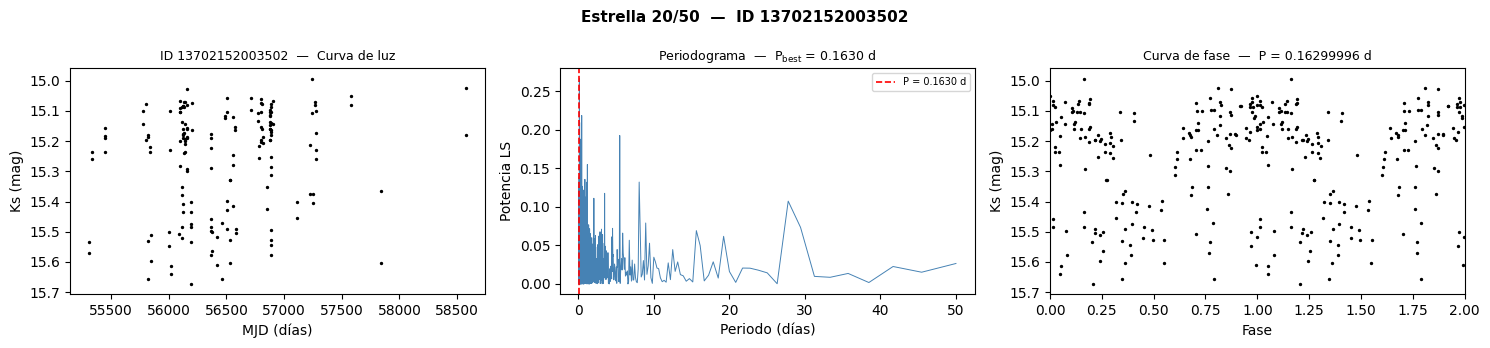

[20/50] ID 13702152003502  →  P = 0.16299996 días


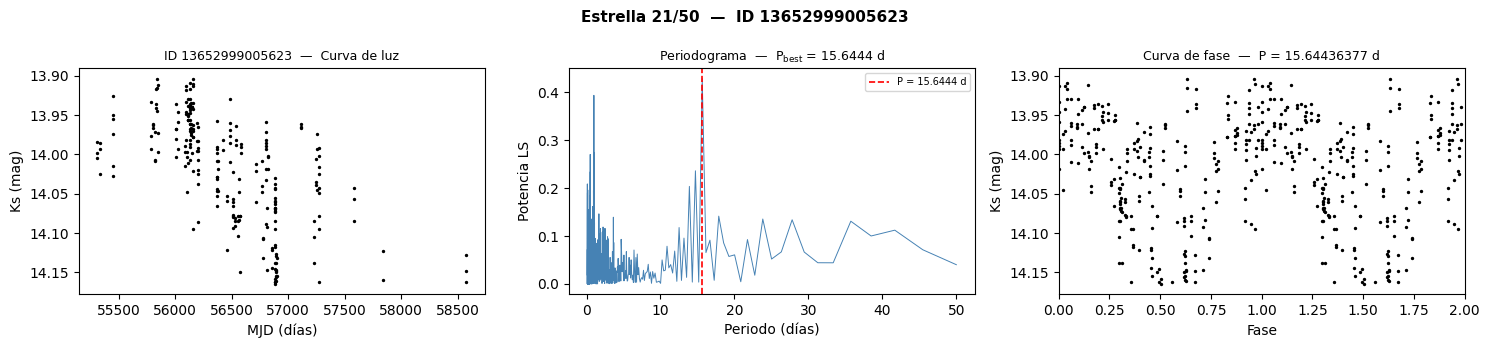

[21/50] ID 13652999005623  →  P = 15.64436377 días


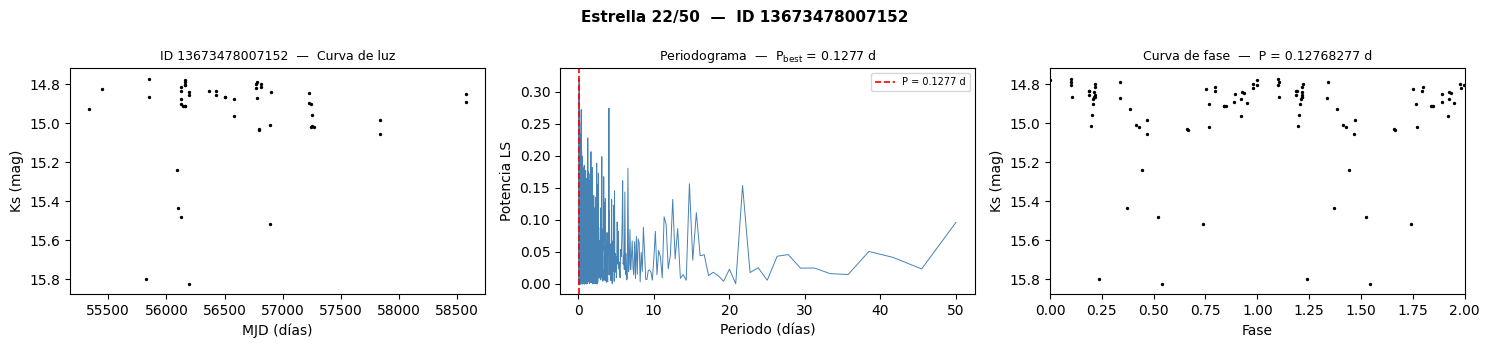

[22/50] ID 13673478007152  →  P = 0.12768277 días


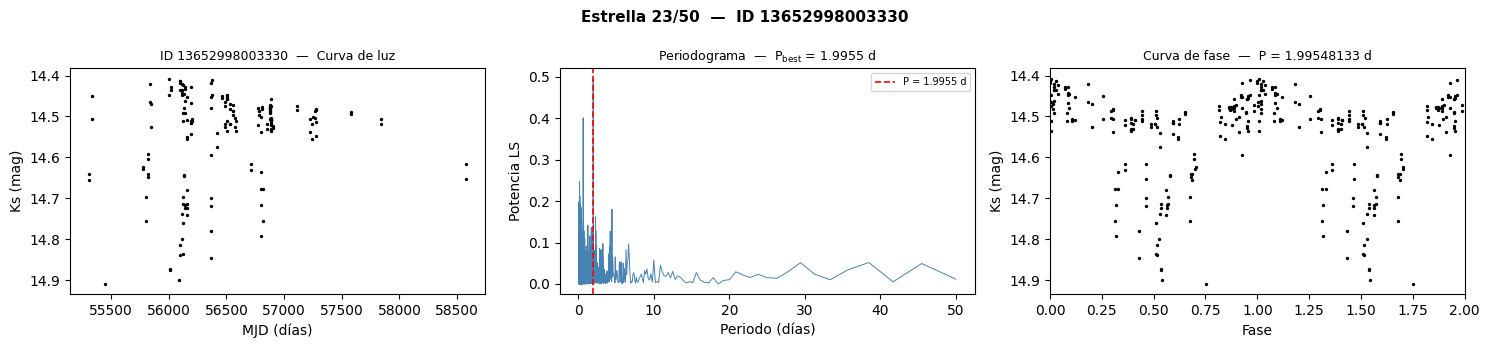

[23/50] ID 13652998003330  →  P = 1.99548133 días


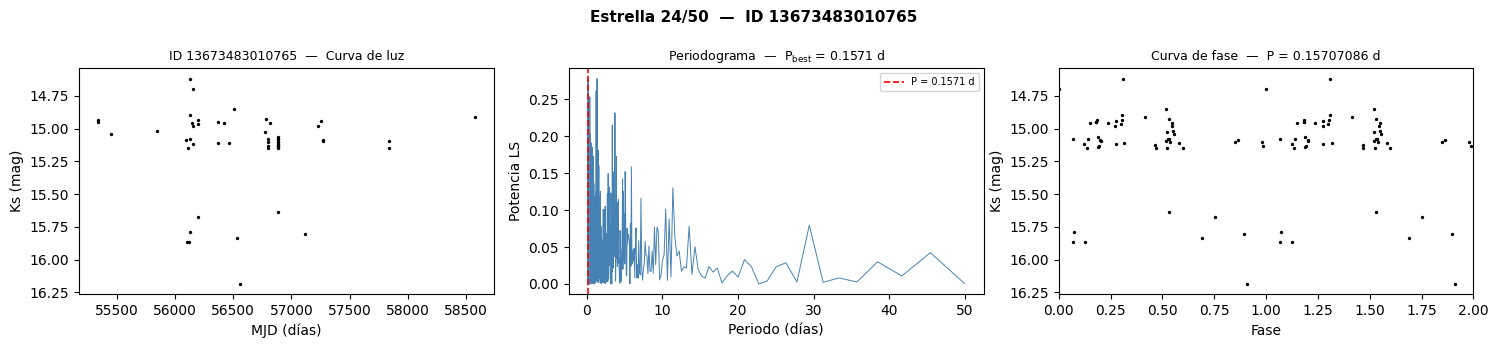

[24/50] ID 13673483010765  →  P = 0.15707086 días


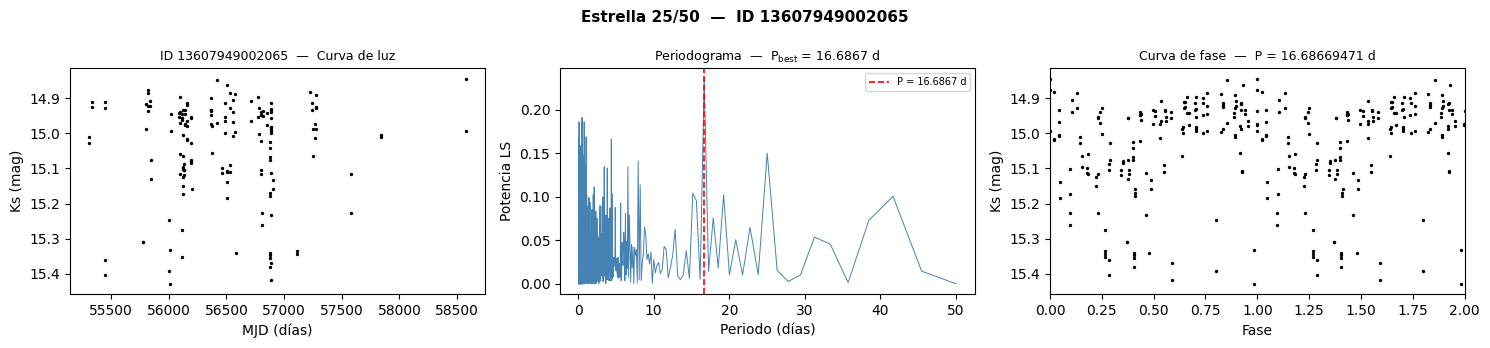

[25/50] ID 13607949002065  →  P = 16.68669471 días


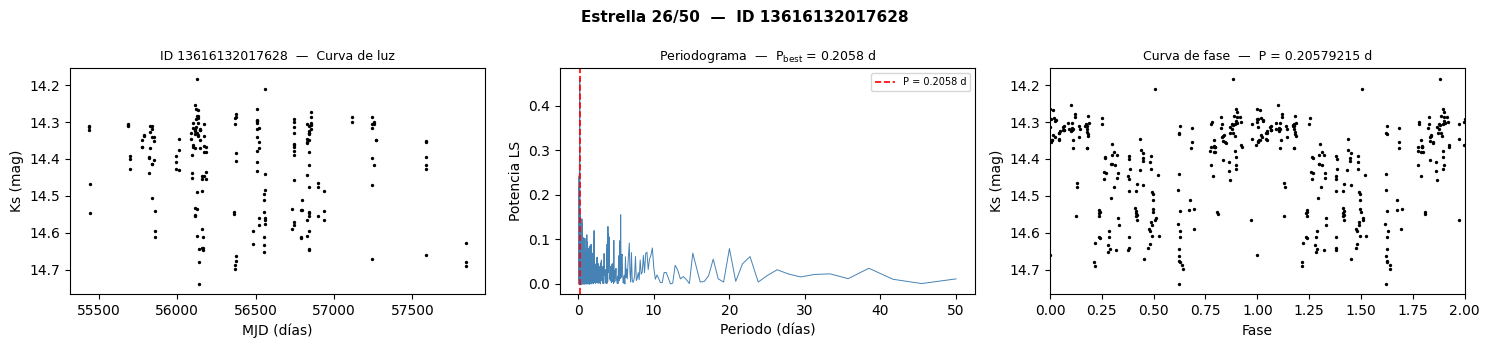

[26/50] ID 13616132017628  →  P = 0.20579215 días


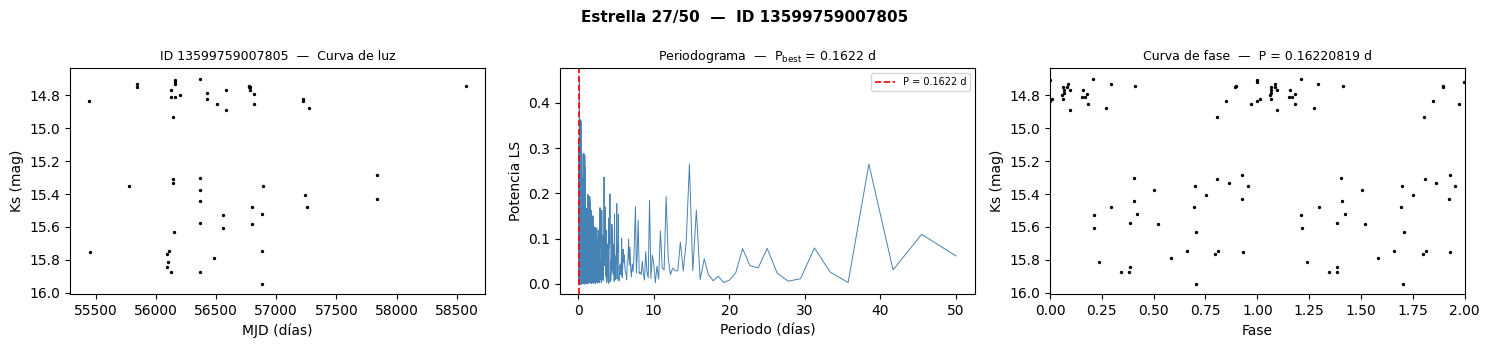

[27/50] ID 13599759007805  →  P = 0.16220819 días


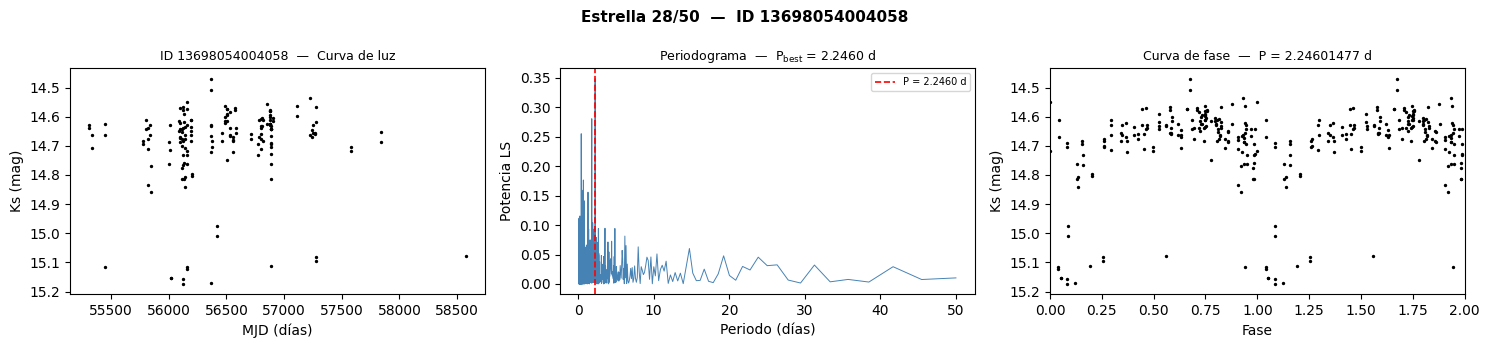

[28/50] ID 13698054004058  →  P = 2.24601477 días


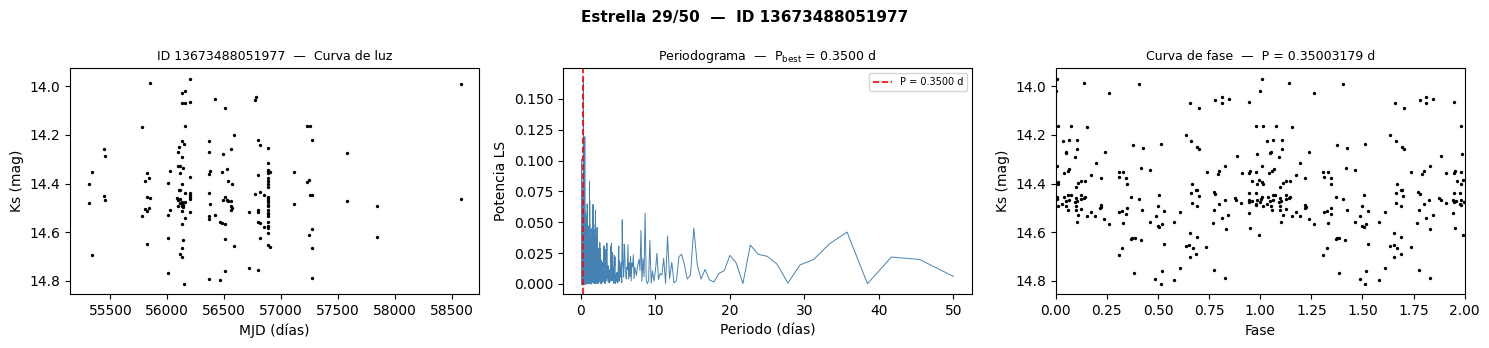

[29/50] ID 13673488051977  →  P = 0.35003179 días


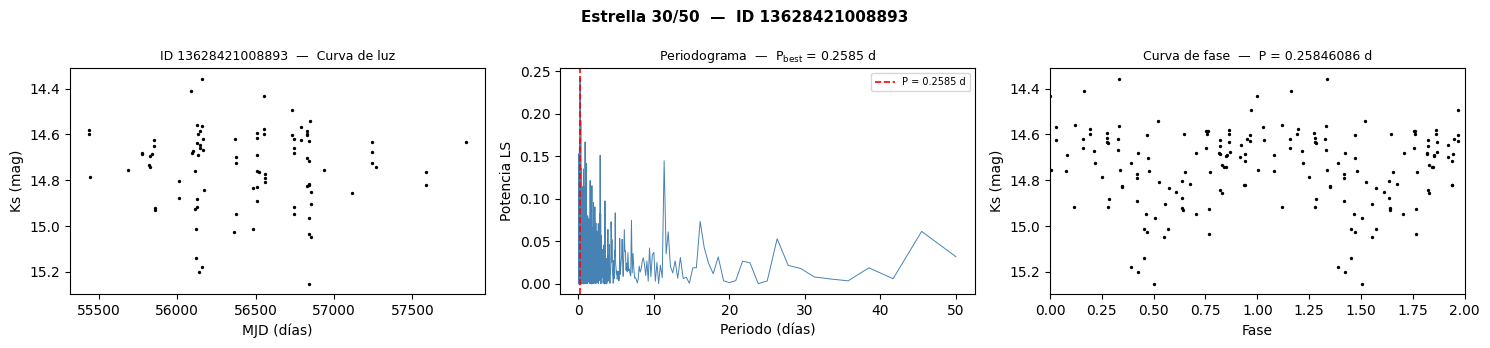

[30/50] ID 13628421008893  →  P = 0.25846086 días


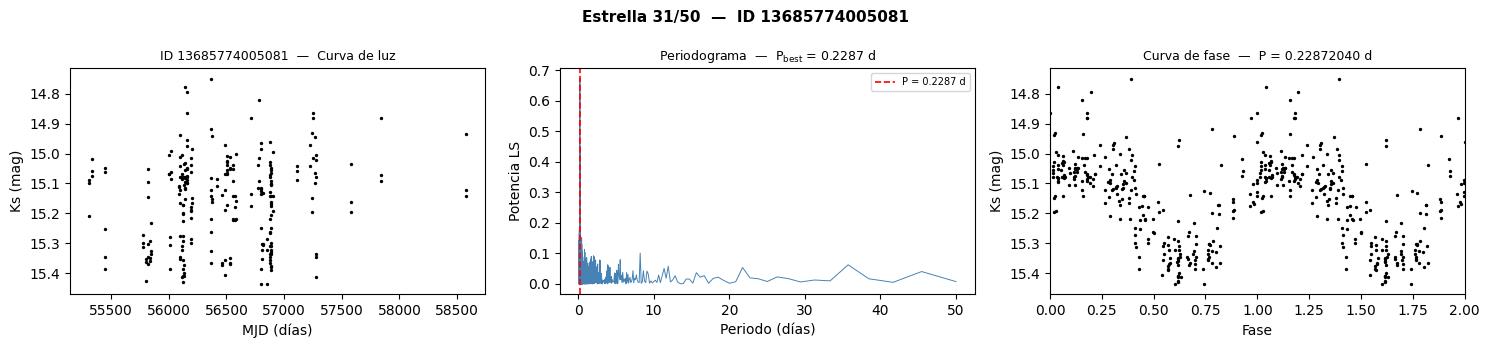

[31/50] ID 13685774005081  →  P = 0.22872040 días


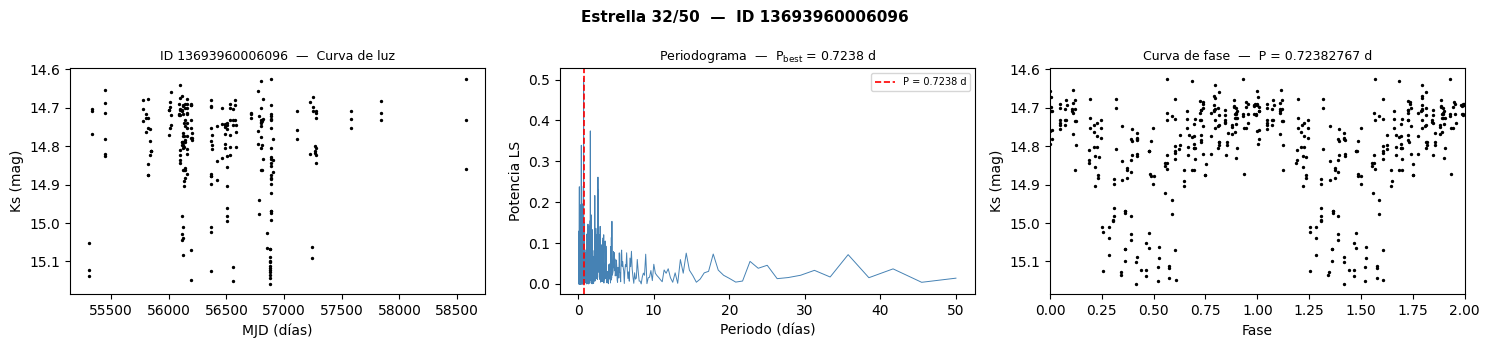

[32/50] ID 13693960006096  →  P = 0.72382767 días


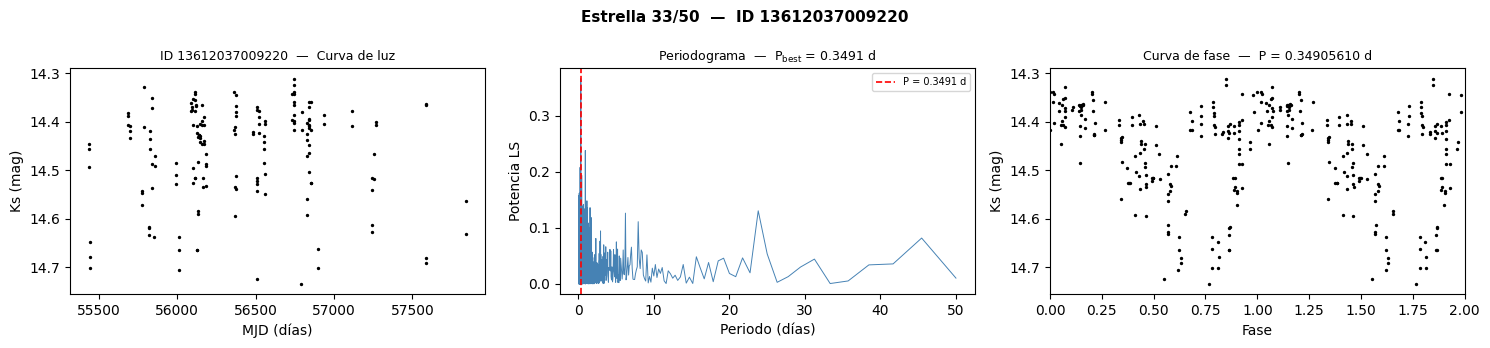

[33/50] ID 13612037009220  →  P = 0.34905610 días


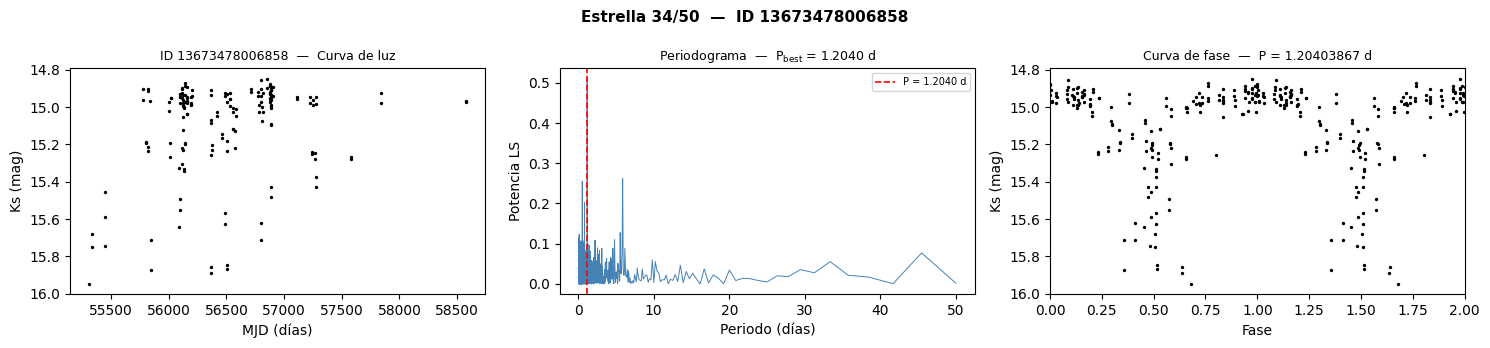

[34/50] ID 13673478006858  →  P = 1.20403867 días


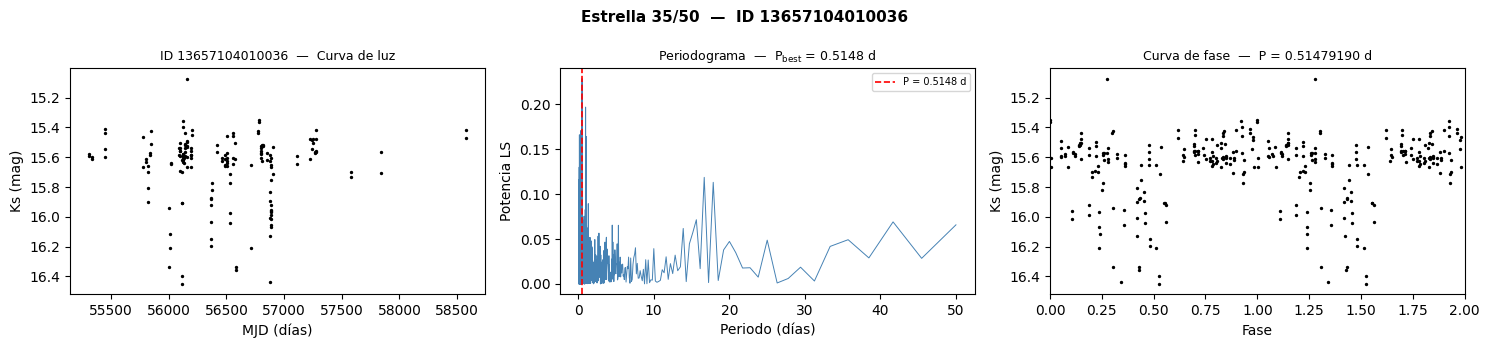

[35/50] ID 13657104010036  →  P = 0.51479190 días


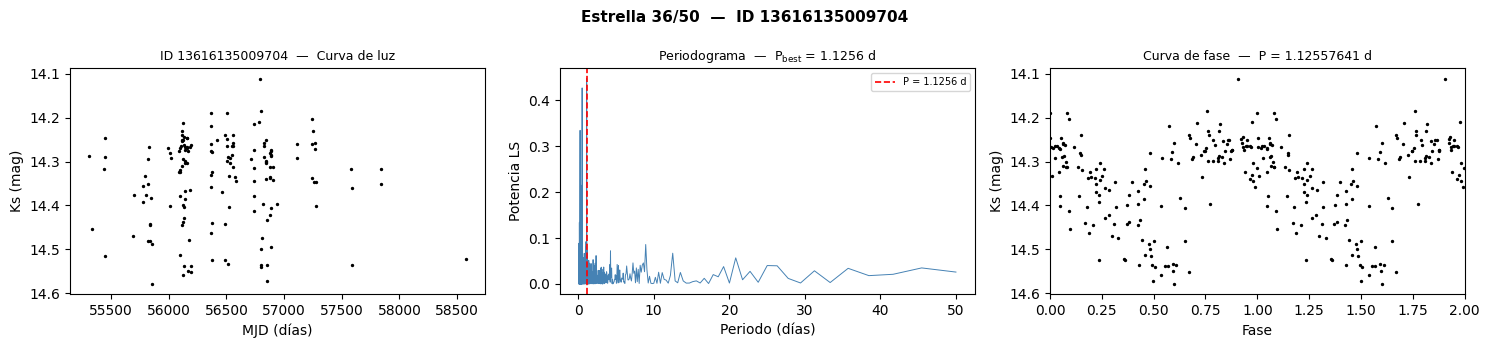

[36/50] ID 13616135009704  →  P = 1.12557641 días


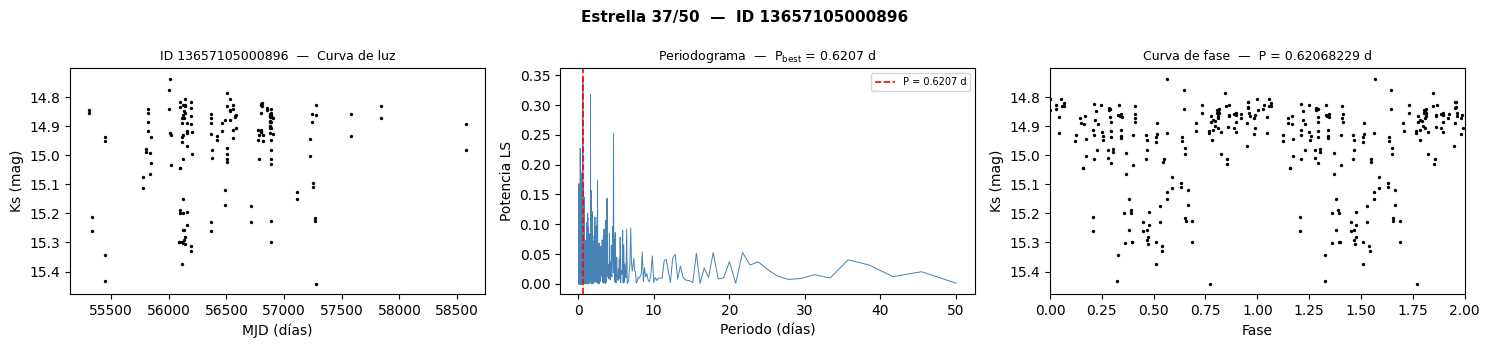

[37/50] ID 13657105000896  →  P = 0.62068229 días


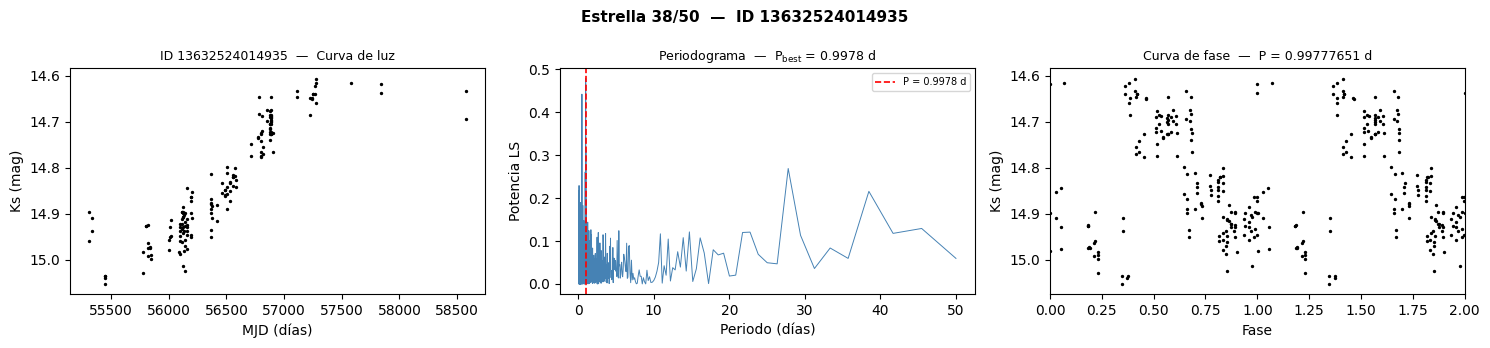

[38/50] ID 13632524014935  →  P = 0.99777651 días


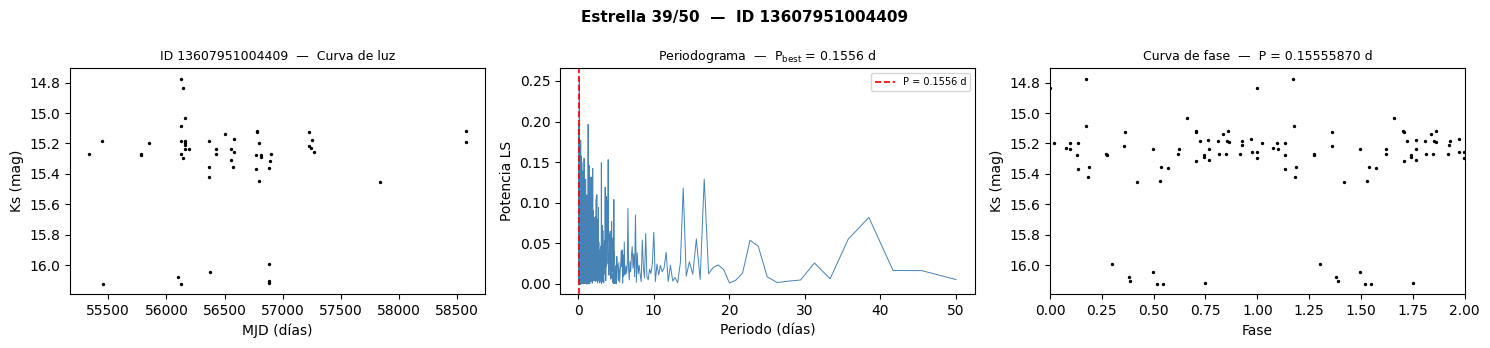

[39/50] ID 13607951004409  →  P = 0.15555870 días


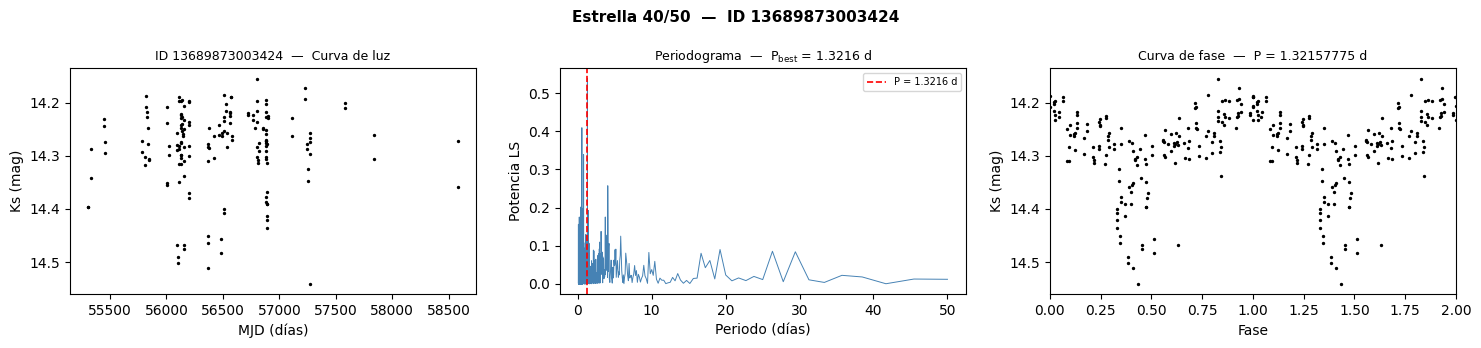

[40/50] ID 13689873003424  →  P = 1.32157775 días


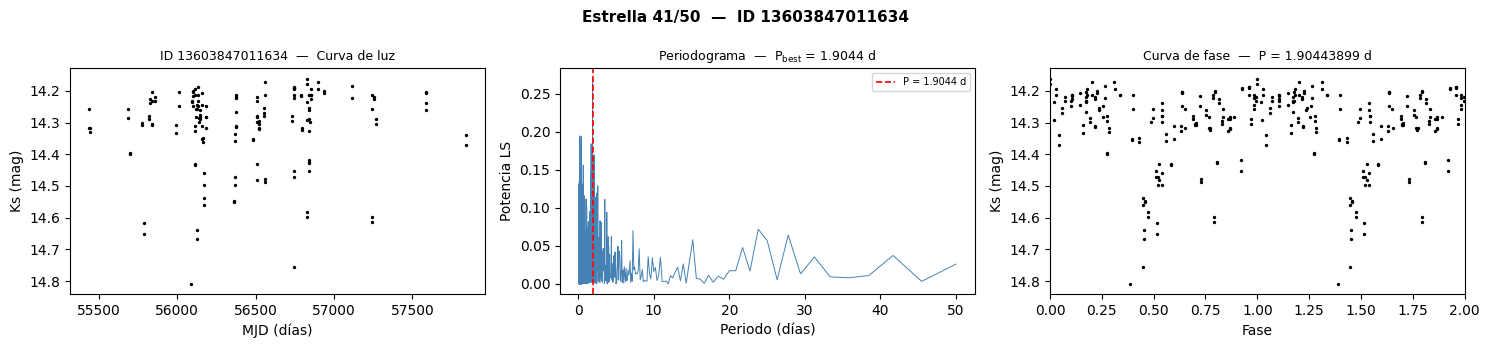

[41/50] ID 13603847011634  →  P = 1.90443899 días


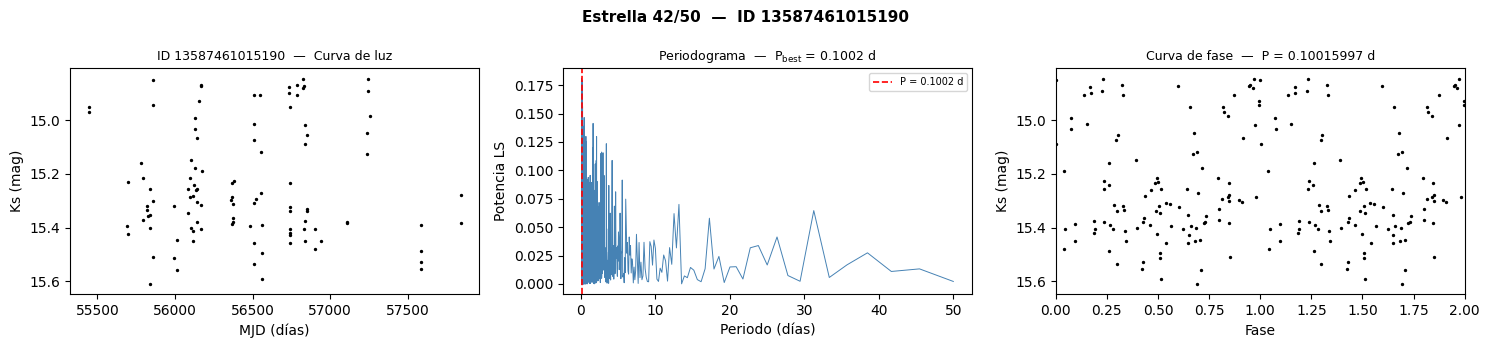

[42/50] ID 13587461015190  →  P = 0.10015997 días


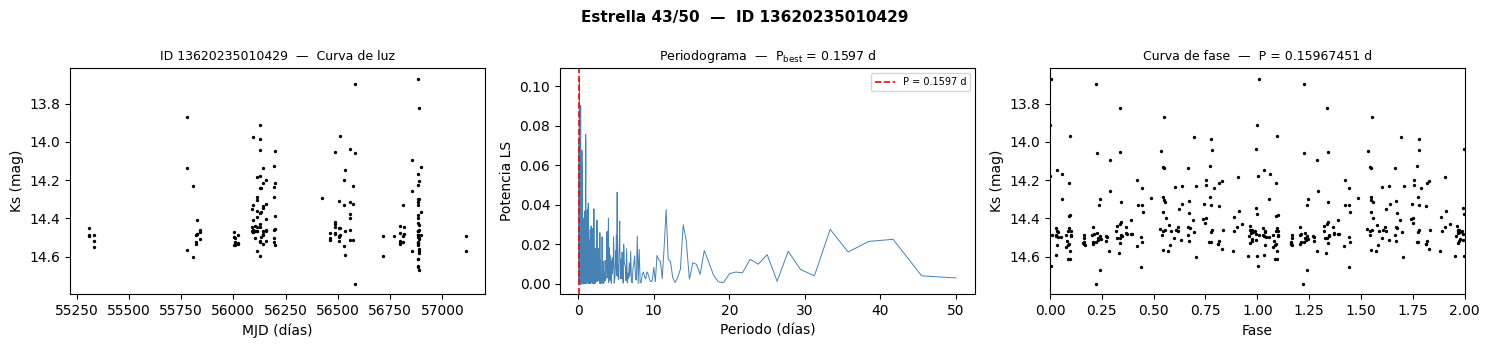

[43/50] ID 13620235010429  →  P = 0.15967451 días


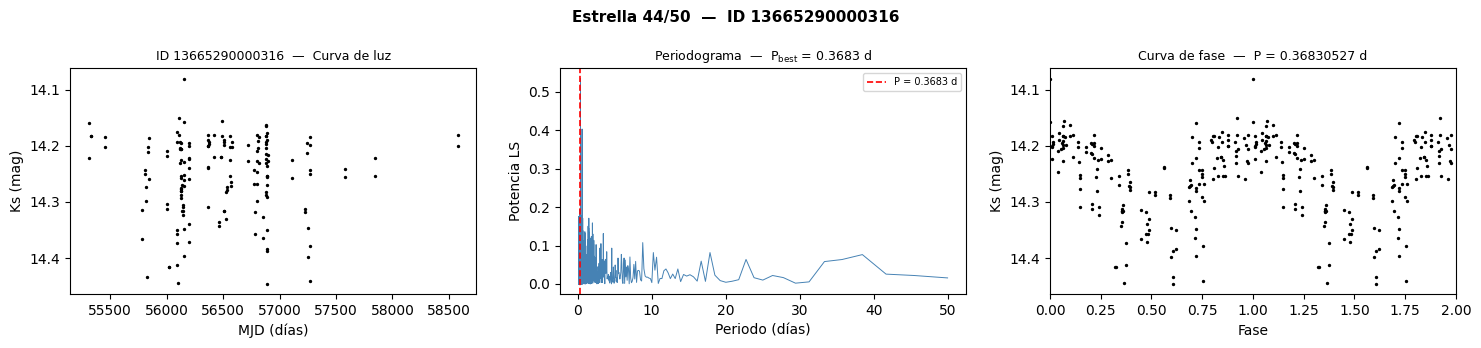

[44/50] ID 13665290000316  →  P = 0.36830527 días


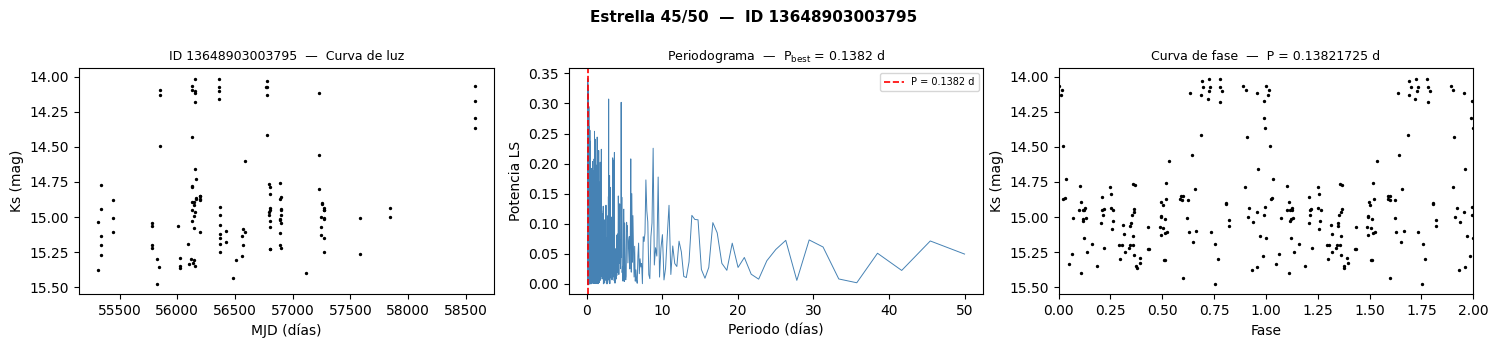

[45/50] ID 13648903003795  →  P = 0.13821725 días


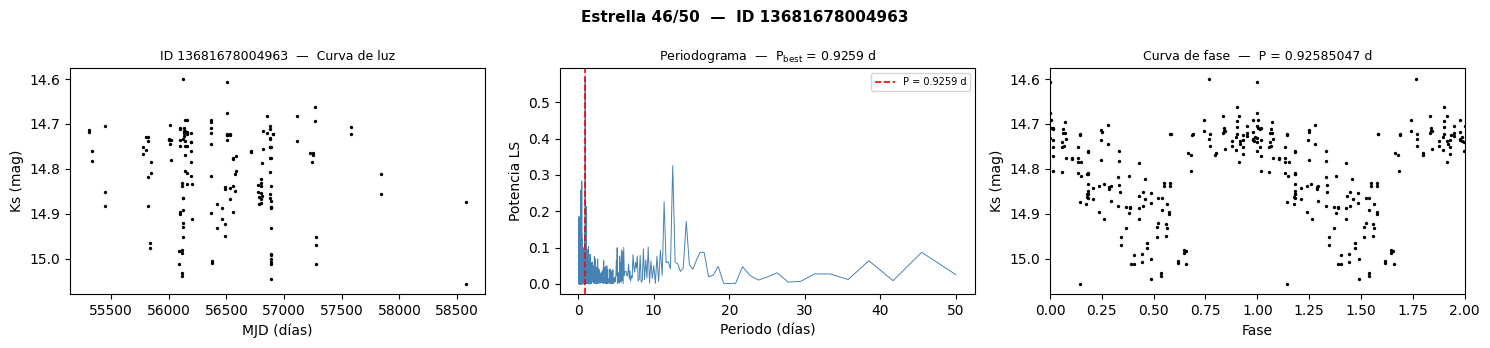

[46/50] ID 13681678004963  →  P = 0.92585047 días


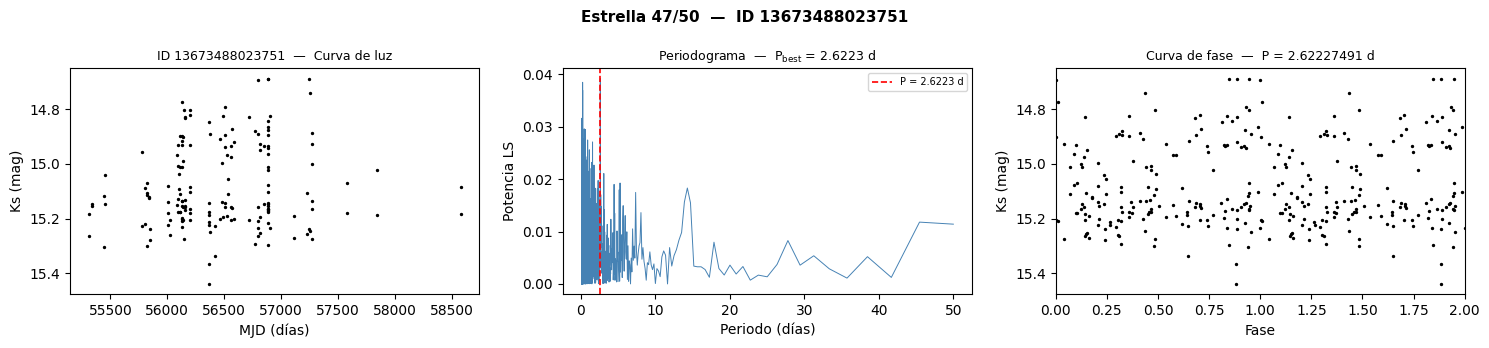

[47/50] ID 13673488023751  →  P = 2.62227491 días


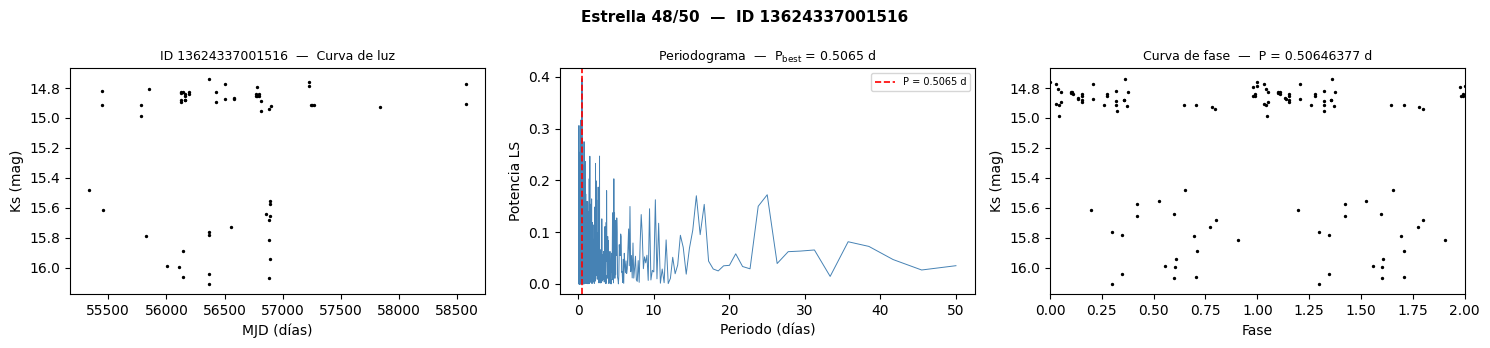

[48/50] ID 13624337001516  →  P = 0.50646377 días


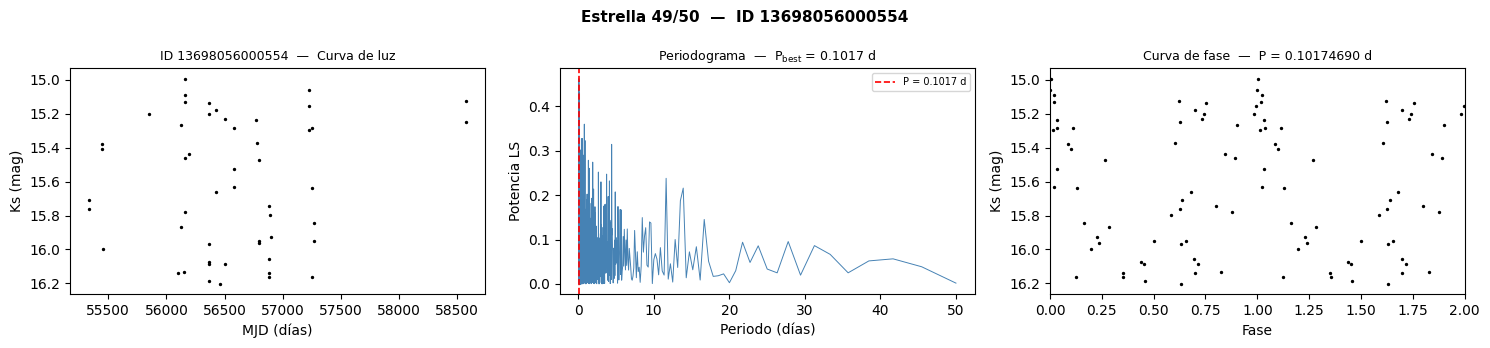

[49/50] ID 13698056000554  →  P = 0.10174690 días


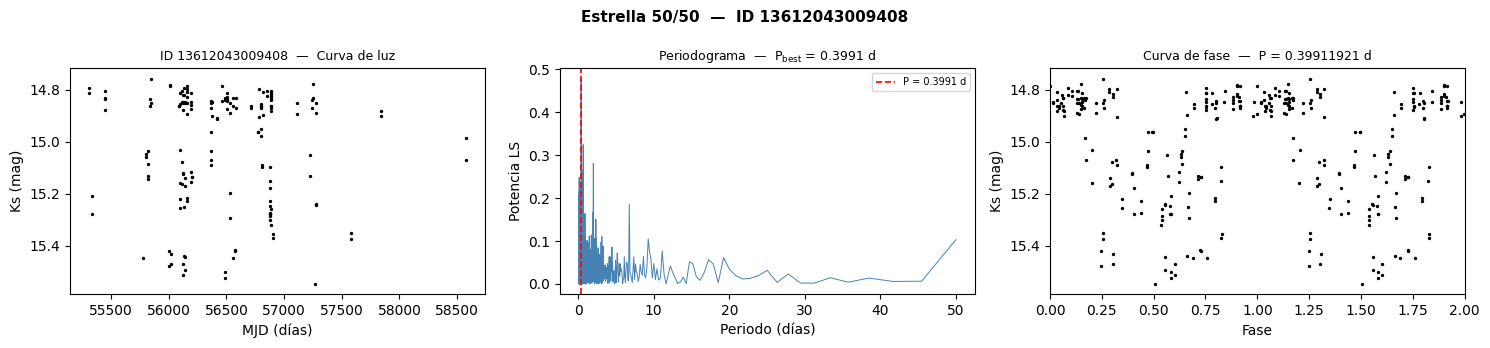

[50/50] ID 13612043009408  →  P = 0.39911921 días


In [33]:
# Tabla de resultados: [índice original, ID, mejor frecuencia, mejor periodo]
resultados = np.zeros((N_STARS, 4))

for i, idx in enumerate(selected_idx):

    t   = mjd_b278[idx]
    ks  = Ks_b278[idx]
    dks = dKs_b278[idx]
    sid = Id_b278[idx]

    # Saltar si la curva de luz tiene menos de 5 puntos válidos
    if len(t) < 5:
        print(f"[{i+1:02d}/{N_STARS}] ID {sid} — muy pocos puntos ({len(t)}), se omite.")
        continue

    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
    fig.suptitle(f'Estrella {i+1}/{N_STARS}  —  ID {sid}', fontsize=11, fontweight='bold')

    best_freq, best_period = plot_star(
        star_id   = sid,
        t         = t,
        mag       = ks,
        dmag      = dks,
        freq_grid = test_frequencies,
        ax_lc     = axes[0],
        ax_pgram  = axes[1],
        ax_phase  = axes[2],
    )

    resultados[i] = [idx, sid, best_freq, best_period]

    plt.tight_layout()
    plt.show()
    print(f"[{i+1:02d}/{N_STARS}] ID {sid:>10.0f}  →  P = {best_period:.8f} días")

## 6 · Resumen de resultados

In [34]:
import pandas as pd

df = pd.DataFrame(
    resultados,
    columns=['idx_original', 'star_id', 'best_frequency_1d', 'best_period_d']
)
df = df[df['best_period_d'] > 0]   # eliminar filas vacías (estrellas omitidas)
df = df.reset_index(drop=True)

print(df.to_string(index=False))
print(f"\nPeriodo medio  : {df['best_period_d'].mean():.4f} d")
print(f"Periodo mediano: {df['best_period_d'].median():.4f} d")
print(f"Rango          : [{df['best_period_d'].min():.4f}, {df['best_period_d'].max():.4f}] d")

 idx_original      star_id  best_frequency_1d  best_period_d
        268.0 1.369397e+13           0.509118       1.964182
          2.0 1.364891e+13           1.507317       0.663430
        105.0 1.365301e+13           0.321456       3.110843
        189.0 1.369806e+13           7.238980       0.138141
         53.0 1.369396e+13           0.227626       4.393180
        269.0 1.361204e+13           2.894815       0.345445
         79.0 1.359567e+13           6.925545       0.144393
        226.0 1.365300e+13           0.592967       1.686436
         81.0 1.360794e+13           4.805369       0.208101
         68.0 1.361205e+13           0.776635       1.287606
        265.0 1.361205e+13           7.744069       0.129131
         18.0 1.365709e+13           6.612110       0.151238
        201.0 1.359566e+13           0.698776       1.431074
        279.0 1.370215e+13           0.592967       1.686436
        187.0 1.370215e+13           6.168910       0.162103
        220.0 1.359566e+

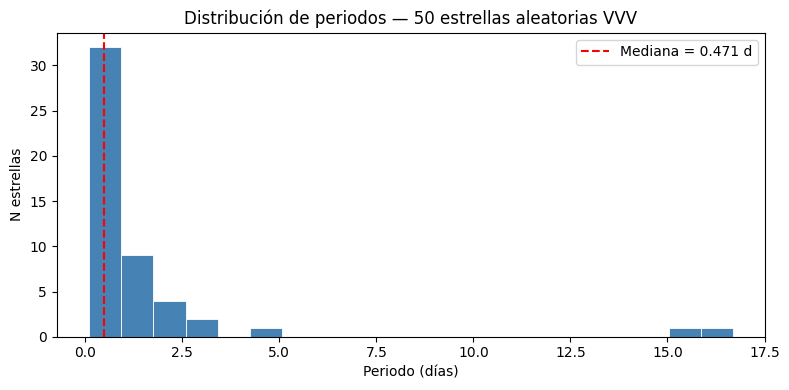

In [35]:
# Histograma de periodos encontrados
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['best_period_d'], bins=20, color='steelblue', edgecolor='white', linewidth=0.6)
ax.axvline(df['best_period_d'].median(), color='red', linestyle='--', lw=1.5,
           label=f"Mediana = {df['best_period_d'].median():.3f} d")
ax.set_xlabel('Periodo (días)')
ax.set_ylabel('N estrellas')
ax.set_title('Distribución de periodos — 50 estrellas aleatorias VVV')
ax.legend()
plt.tight_layout()
plt.show()